# Lab 4: Flash Flood Risk Modeling
## ภม.338 Geographic Data Science

**โมเดล:** Multi-Criteria Flash Flood Risk Index (FFRI)  
**พื้นที่ศึกษา:** อำเภอศรีสำโรง จังหวัดสุโขทัย  
**เครื่องมือ:** Google Earth Engine Python API  
**ข้อมูล validate** ข้อมูลพื้นที่น้ำท่วมซ้ำซาก จากกรมพัฒนาที่ดิน โดยจัดการข้อมูลโดยโปรแกรม arcGIS pro เริ่มจากแปลงพื้นที่(polygon)เป็นจุด สร้างClass 1 คือจุดเกิด และ สร้างระยะห่างจากจุดเกิด 1 กิโลเมตร ให้มีจำนวนจุดเท่ากันกับจุดเกิด กำหนดให้ Class  0 คือจุดไม่เกิด

### ปัจจัยที่ใช้ (10 Factors)
| # | Factor | Dataset | Weight |
|---|--------|---------|--------|
| 1 | Slope | SRTM DEM | 0.15 |
| 2 | Elevation (DEM) | SRTM DEM | 0.10 |
| 3 | TWI | SRTM + HydroSHEDS | 0.15 |
| 4 | Plan Curvature | SRTM DEM | 0.10 |
| 5 | NDVI (Vegetation) | Sentinel-2 | 0.10 |
| 6 | Soil Moisture Proxy | ERA5 | 0.05 |
| 7 | Rainfall Intensity | ERA5 | 0.15 |
| 8 | Distance to River | HydroSHEDS | 0.10 |
| 9 | Land Use/Cover | MODIS MCD12Q1 | 0.05 |
| 10 | Historical Water (JRC GSW) | JRC GSW | 0.05 |


## 0. Setup & Initialization

In [1]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import geopandas as gpd

ee.Authenticate()  # รันครั้งแรกเท่านั้น
ee.Initialize(project='ee-khehathancencira')
print('GEE initialized successfully')

GEE initialized successfully


## 1. กำหนดพื้นที่ศึกษา (Area of Interest)

In [2]:
# AOI: อำเภอศรีสำโรง จังหวัดสุโขทัย
AOI = (
    ee.FeatureCollection('FAO/GAUL/2015/level2')
    .filter(ee.Filter.eq('ADM1_NAME', 'Sukhothai'))
    .filter(ee.Filter.eq('ADM2_NAME', 'Si Samrong'))
    .geometry()
)

Map = geemap.Map()
Map.centerObject(AOI, zoom=10)
Map.addLayer(AOI, {'color': 'red'}, 'Si Samrong AOI')
Map

Map(center=[17.167732372207865, 99.72800371682598], controls=(WidgetControl(options=['position', 'transparent_…

## 2. โหลดข้อมูล Validation — Point-based

ใช้ข้อมูลจากไฟล์ `point_flood.shp` แบ่งเป็น:
- **Class 1:** จุดที่เกิดน้ำท่วมซ้ำซาก (Flood)
- **Class 0:** จุดที่ไม่เคยเกิดน้ำท่วม (Non-flood)

In [3]:
import geopandas as gpd

gdf = gpd.read_file('/content/point_flood.shp')
print(gdf.columns)

val_points = geemap.geopandas_to_ee(gdf)
val_points = val_points.filterBounds(AOI)
val_points = val_points.map(lambda f: f.set('label', f.get('Class')))

n_total    = val_points.size().getInfo()
n_flood    = val_points.filter(ee.Filter.eq('label', 1)).size().getInfo()
n_no_flood = val_points.filter(ee.Filter.eq('label', 0)).size().getInfo()

print(f'✅ Validation points loaded')
print(f'   Total   : {n_total} points')
print(f'   Flood   : {n_flood} points  (label=1)')
print(f'   No Flood: {n_no_flood} points  (label=0)')

Index(['CID', 'Class', 'FID_Point_', 'ORIG_FID', 'FID_Amphoe', 'AMP_CODE',
       'PRV_CODE', 'AMP_NAME_T', 'AMP_NAME_E', 'Shape_Leng', 'TH_Provinc',
       'TH_Provi_1', 'geometry'],
      dtype='object')
✅ Validation points loaded
   Total   : 11874 points
   Flood   : 5805 points  (label=1)
   No Flood: 6069 points  (label=0)


## 3. โหลดและเตรียม Dataset แต่ละ Factor

In [4]:
# ==========================================
# FACTOR 1 & 2: Slope + DEM จาก SRTM
# ==========================================
srtm  = ee.Image('USGS/SRTMGL1_003').clip(AOI)
dem   = srtm.select('elevation')
slope = ee.Terrain.slope(dem)
print('✅ SRTM DEM and Slope loaded')

✅ SRTM DEM and Slope loaded


In [5]:
# ==========================================
# FACTOR 3: TWI (Topographic Wetness Index)
# TWI = ln(As / tan(β))
# ==========================================
slope_rad    = slope.multiply(np.pi / 180)
tan_slope    = slope_rad.tan().max(ee.Image(0.001))
flow_acc     = ee.Image('WWF/HydroSHEDS/15ACC').clip(AOI)
specific_area = flow_acc.multiply(250000).max(ee.Image(1))
twi = (specific_area.divide(tan_slope)).log().rename('TWI')
print('✅ TWI computed from HydroSHEDS flow accumulation + SRTM slope')

✅ TWI computed from HydroSHEDS flow accumulation + SRTM slope


In [6]:
# ==========================================
# FACTOR 4: Plan Curvature (ความโค้งแนวราบ)
# ==========================================
# Plan Curvature บอกทิศทางการรวมตัว/แยกตัวของน้ำไหล
# ค่าลบ (concave) = น้ำรวมตัว = เสี่ยงน้ำท่วมสูง
# ค่าบวก (convex) = น้ำกระจาย = เสี่ยงต่ำกว่า
#
# อ้างอิง: Zevenbergen & Thorne (1987) — Quantitative analysis of land surface topography
# Plan Curvature = -∂²z/∂x² (simplified using ee.Terrain)

terrain_vals = ee.Terrain.products(dem)

# GEE ไม่มี plan_curvature โดยตรง — คำนวณจาก gradient ของ slope direction
# Proxy: ใช้ aspect + slope gradient แทน true plan curvature
aspect = terrain_vals.select('aspect')

# Approximate plan curvature โดยคำนวณ Laplacian ของ DEM
# Laplacian ≈ ∇²z สะท้อนความโค้งรวม (positive = hill, negative = valley)
kernel = ee.Kernel.laplacian8(normalize=False)
plan_curvature = dem.convolve(kernel).rename('plan_curvature').clip(AOI)

# ค่าลบมาก (valley/concave) = น้ำรวมกัน = เสี่ยงสูง
# → invert เพื่อให้ค่าสูง = เสี่ยงสูง (Flood Risk)
plan_curvature_inv = plan_curvature.multiply(-1).rename('plan_curvature_inv')

print('✅ Plan Curvature computed (Laplacian of DEM)')
print('   ค่า concave (valley/แอ่ง) = เสี่ยงน้ำท่วมสูง')

✅ Plan Curvature computed (Laplacian of DEM)
   ค่า concave (valley/แอ่ง) = เสี่ยงน้ำท่วมสูง


In [7]:
# ==========================================
# FACTOR 5: NDVI จาก Sentinel-2
# ==========================================
# NDVI ต่ำ (พื้นดินโล่ง, เมือง) → runoff มาก → เสี่ยงสูง
# อ้างอิง: Pradhan & Lee (2010) — Flood susceptibility assessment

RAIN_YEAR  = 2024
RAIN_START = f'{RAIN_YEAR}-05-01'
RAIN_END   = f'{RAIN_YEAR}-10-01'

s2 = (
    ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterDate(RAIN_START, RAIN_END)
    .filterBounds(AOI)
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20))
    .median()
    .clip(AOI)
)

ndvi = s2.normalizedDifference(['B8', 'B4']).rename('NDVI')
# NDVI ต่ำ = เสี่ยงสูง → invert
ndvi_inv = ndvi.multiply(-1).rename('ndvi_inv')

print(f'✅ NDVI loaded from Sentinel-2 ({RAIN_START} to {RAIN_END})')
print('   NDVI ต่ำ (พื้นโล่ง/เมือง) → runoff สูง → เสี่ยงน้ำท่วมมาก')

✅ NDVI loaded from Sentinel-2 (2024-05-01 to 2024-10-01)
   NDVI ต่ำ (พื้นโล่ง/เมือง) → runoff สูง → เสี่ยงน้ำท่วมมาก


In [8]:
# ==========================================
# FACTOR 6: Antecedent Soil Moisture (ERA5)
# ==========================================
# ดินที่ชื้นอยู่แล้วรับน้ำได้น้อย → น้ำไหลบ่าเร็ว → เสี่ยงสูง
# อ้างอิง: Brocca et al. (2012) — Soil moisture role in runoff response
# ใช้ ERA5 Volumetric Soil Water Layer 1 (0-7 cm depth)

soil_moisture = (
    ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
    .filterDate(RAIN_START, RAIN_END)
    .select('volumetric_soil_water_layer_1')  # หน่วย m³/m³
    .max()  # ใช้ maximum ช่วง wet season
    .clip(AOI)
    .rename('soil_moisture')
)

print(f'✅ Soil Moisture loaded from ERA5 (0-7 cm depth, wet season max)')
print('   ดินชื้นสูง → รับน้ำได้น้อย → น้ำไหลบ่า → เสี่ยงสูง')

✅ Soil Moisture loaded from ERA5 (0-7 cm depth, wet season max)
   ดินชื้นสูง → รับน้ำได้น้อย → น้ำไหลบ่า → เสี่ยงสูง


In [9]:
# ==========================================
# FACTOR 7: Rainfall Intensity จาก ERA5
# ==========================================
era5 = (
    ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY_AGGR')
    .filterDate(RAIN_START, RAIN_END)
    .select('total_precipitation_sum')
)
rainfall = era5.max().multiply(1000).clip(AOI).rename('rainfall_mm')
print(f'✅ ERA5 Rainfall loaded: {RAIN_START} to {RAIN_END}')

✅ ERA5 Rainfall loaded: 2024-05-01 to 2024-10-01


In [10]:
# ==========================================
# FACTOR 8: Distance to River จาก HydroSHEDS
# ==========================================
hydrosheds_rivers = ee.FeatureCollection('WWF/HydroSHEDS/v1/FreeFlowingRivers')
river_raster = hydrosheds_rivers.filter(
    ee.Filter.gte('RIV_ORD', 5)
).reduceToImage(
    properties=['RIV_ORD'],
    reducer=ee.Reducer.first()
).gt(0).unmask(0).clip(AOI)

dist_river = river_raster.Not().cumulativeCost(
    source=river_raster,
    maxDistance=50000
).rename('dist_to_river').clip(AOI)
print('✅ Distance to River computed from HydroSHEDS')

✅ Distance to River computed from HydroSHEDS


In [11]:
# ==========================================
# FACTOR 9: Land Use / Land Cover (MODIS)
# ==========================================
modis_lc = (
    ee.ImageCollection('MODIS/061/MCD12Q1')
    .filterDate(f'{RAIN_YEAR}-01-01', f'{RAIN_YEAR}-12-31')
    .first()
    .select('LC_Type1')
    .clip(AOI)
)

lulc_classes = [1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17]
lulc_risk    = [1,  1,  1,  1,  1,  2,  3,  2,  3,  3,  4,  3,  5,  2,  1,  4,  1]
lulc_risk_map = modis_lc.remap(lulc_classes, lulc_risk).rename('lulc_risk')
print('✅ MODIS LULC loaded and remapped to risk scores (1-5)')

✅ MODIS LULC loaded and remapped to risk scores (1-5)


In [12]:
# ==========================================
# FACTOR 10: JRC Global Surface Water
# ==========================================
jrc_gsw = (
    ee.Image('JRC/GSW1_4/GlobalSurfaceWater')
    .select('occurrence')
    .clip(AOI)
    .unmask(0)
)
print('✅ JRC GSW Occurrence loaded (1984-2021)')

✅ JRC GSW Occurrence loaded (1984-2021)


## 4. Normalize แต่ละ Factor (Min-Max Normalization)

**วิธี:** Min-Max Normalization พร้อม Percentile Clipping (P1–P99) ลด outlier

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

In [13]:
def minmax_normalize(image, aoi, scale=500, percentile_clip=True):
    """
    Normalize image ด้วย Min-Max Normalization ในช่วง [0, 1]
    percentile_clip=True จะ clip ที่ P1-P99 ก่อน normalize เพื่อลด outlier
    """
    if percentile_clip:
        pct = image.reduceRegion(
            reducer=ee.Reducer.percentile([1, 99]),
            geometry=aoi, scale=scale, maxPixels=1e9, bestEffort=True
        )
        band    = image.bandNames().get(0)
        p1      = ee.Number(pct.get(ee.String(band).cat('_p1')))
        p99     = ee.Number(pct.get(ee.String(band).cat('_p99')))
        image   = image.clamp(p1, p99)
        min_val = p1
        max_val = p99
    else:
        stats   = image.reduceRegion(
            reducer=ee.Reducer.minMax(),
            geometry=aoi, scale=scale, maxPixels=1e9, bestEffort=True
        )
        band    = image.bandNames().get(0)
        min_val = ee.Number(stats.get(ee.String(band).cat('_min')))
        max_val = ee.Number(stats.get(ee.String(band).cat('_max')))

    normalized = image.subtract(min_val).divide(max_val.subtract(min_val))
    return normalized.clamp(0, 1)


SCALE = 500  # meters

slope_n         = minmax_normalize(slope,              AOI, SCALE).rename('slope_n')
dem_inv_n       = minmax_normalize(dem,                AOI, SCALE).multiply(-1).add(1).rename('dem_inv_n')
twi_n           = minmax_normalize(twi,                AOI, SCALE).rename('twi_n')
plan_curv_n     = minmax_normalize(plan_curvature_inv, AOI, SCALE).rename('plan_curv_n')  # ค่า concave สูง = เสี่ยงสูง
ndvi_inv_n      = minmax_normalize(ndvi_inv,           AOI, SCALE).rename('ndvi_inv_n')    # NDVI ต่ำ = เสี่ยงสูง
soil_moist_n    = minmax_normalize(soil_moisture,      AOI, SCALE).rename('soil_moist_n')  # ชื้น = เสี่ยงสูง
rainfall_n      = minmax_normalize(rainfall,           AOI, SCALE).rename('rainfall_n')
dist_inv_n      = minmax_normalize(dist_river,         AOI, SCALE).multiply(-1).add(1).rename('dist_inv_n')
lulc_n          = minmax_normalize(lulc_risk_map,      AOI, SCALE, percentile_clip=False).rename('lulc_n')
jrc_n           = minmax_normalize(jrc_gsw,            AOI, SCALE).rename('jrc_n')

print('✅ All 10 factors normalized to [0, 1]')
print('   Inverse applied where needed (ต่ำ = เสี่ยงสูง)')

✅ All 10 factors normalized to [0, 1]
   Inverse applied where needed (ต่ำ = เสี่ยงสูง)


## 5. สร้าง Flash Flood Risk Index (FFRI)

### สมการ Weighted Linear Combination (WLC)

$$FFRI = 0.15 \cdot slope_n + 0.10 \cdot (1-dem_n) + 0.15 \cdot twi_n + 0.10 \cdot planCurv_n + 0.10 \cdot ndvi_{inv_n} + 0.05 \cdot soilMoist_n + 0.15 \cdot rain_n + 0.10 \cdot (1-distRiver_n) + 0.05 \cdot lulc_n + 0.05 \cdot jrc_n$$

In [14]:
# ==========================================
# กำหนด Weights (ต้องรวม = 1.00)
# ==========================================
WEIGHTS = {
    'slope':      0.15,   # Tehrany et al. 2015
    'dem':        0.10,   # Fernández & Lutz 2010
    'twi':        0.15,   # Rahmati et al. 2016
    'plan_curv':  0.10,   # Zevenbergen & Thorne 1987; Park et al. 2013
    'ndvi':       0.10,   # Pradhan & Lee 2010
    'soil_moist': 0.05,   # Brocca et al. 2012
    'rainfall':   0.15,   # Gaume et al. 2009
    'river':      0.10,   # Beven & Kirkby 1979
    'lulc':       0.05,   # USDA Curve Number
    'jrc':        0.05,   # Pekel et al. 2016
}

assert abs(sum(WEIGHTS.values()) - 1.0) < 1e-9, 'ERROR: Weights must sum to 1.0!'
print(f'✅ Weights validated. Sum = {sum(WEIGHTS.values()):.2f}')

# ==========================================
# คำนวณ FFRI
# ==========================================
FFRI = (
    slope_n     .multiply(WEIGHTS['slope'])
    .add(dem_inv_n    .multiply(WEIGHTS['dem']))
    .add(twi_n        .multiply(WEIGHTS['twi']))
    .add(plan_curv_n  .multiply(WEIGHTS['plan_curv']))
    .add(ndvi_inv_n   .multiply(WEIGHTS['ndvi']))
    .add(soil_moist_n .multiply(WEIGHTS['soil_moist']))
    .add(rainfall_n   .multiply(WEIGHTS['rainfall']))
    .add(dist_inv_n   .multiply(WEIGHTS['river']))
    .add(lulc_n       .multiply(WEIGHTS['lulc']))
    .add(jrc_n        .multiply(WEIGHTS['jrc']))
).rename('FFRI').clip(AOI)

print('✅ FFRI computed successfully (10 factors)')

✅ Weights validated. Sum = 1.00
✅ FFRI computed successfully (10 factors)


In [15]:
# ==========================================
# แบ่งระดับความเสี่ยง (Thresholds)
# อ้างอิง: Tehrany et al. (2015) — 5-class equal-interval
# ==========================================
#risk_class = (
 #   FFRI.where(FFRI.lte(0.2), 1)
 #       .where(FFRI.gt(0.2).And(FFRI.lte(0.4)), 2)
 #       .where(FFRI.gt(0.4).And(FFRI.lte(0.6)), 3)
 #       .where(FFRI.gt(0.6).And(FFRI.lte(0.8)), 4)
 #       .where(FFRI.gt(0.8), 5)
 #       .rename('risk_class')
#)

#print('✅ Risk classification complete')
#print('   Class 1: Very Low  (FFRI ≤ 0.2)')
#print('   Class 2: Low       (0.2 < FFRI ≤ 0.4)')
#print('   Class 3: Moderate  (0.4 < FFRI ≤ 0.6)')
#print('   Class 4: High      (0.6 < FFRI ≤ 0.8)')
#print('   Class 5: Very High (FFRI > 0.8)')

In [16]:
# คำนวณ percentile ของ FFRI ใน AOI ก่อน
ffri_pct = FFRI.reduceRegion(
    reducer=ee.Reducer.percentile([20, 40, 60, 80]),
    geometry=AOI,
    scale=SCALE,
    maxPixels=1e9,
    bestEffort=True
).getInfo()

p20 = ffri_pct['FFRI_p20']
p40 = ffri_pct['FFRI_p40']
p60 = ffri_pct['FFRI_p60']
p80 = ffri_pct['FFRI_p80']

print(f'Percentile thresholds:')
print(f'  P20 = {p20:.3f}  (Very Low / Low boundary)')
print(f'  P40 = {p40:.3f}  (Low / Moderate boundary)')
print(f'  P60 = {p60:.3f}  (Moderate / High boundary)')
print(f'  P80 = {p80:.3f}  (High / Very High boundary)')

# แบ่ง class ด้วย percentile threshold
risk_class = (
    FFRI.where(FFRI.lte(p20), 1)
        .where(FFRI.gt(p20).And(FFRI.lte(p40)), 2)
        .where(FFRI.gt(p40).And(FFRI.lte(p60)), 3)
        .where(FFRI.gt(p60).And(FFRI.lte(p80)), 4)
        .where(FFRI.gt(p80), 5)
        .rename('risk_class')
)

Percentile thresholds:
  P20 = 0.347  (Very Low / Low boundary)
  P40 = 0.376  (Low / Moderate boundary)
  P60 = 0.398  (Moderate / High boundary)
  P80 = 0.427  (High / Very High boundary)


## 6. แสดงผลลัพธ์ (Visualization)

In [17]:
Map = geemap.Map()
Map.centerObject(AOI, zoom=9)

risk_palette = ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']

Map.addLayer(FFRI,       {'min': 0, 'max': 1, 'palette': risk_palette}, 'Flash Flood Risk Index (FFRI)')
Map.addLayer(risk_class, {'min': 1, 'max': 5, 'palette': risk_palette}, 'Risk Class (1=Very Low, 5=Very High)')
Map.addLayer(ee.Image().paint(AOI, 0, 2), {'palette': ['black']}, 'AOI Boundary')

legend_dict = {
    'Very Low (≤0.2)':    '#1a9641',
    'Low (0.2-0.4)':      '#a6d96a',
    'Moderate (0.4-0.6)': '#ffffbf',
    'High (0.6-0.8)':     '#fdae61',
    'Very High (>0.8)':   '#d7191c',
}
Map.add_legend(title='Flash Flood Risk', legend_dict=legend_dict)
Map

Map(center=[17.167732372207748, 99.72800371682601], controls=(WidgetControl(options=['position', 'transparent_…


📊 พื้นที่แต่ละระดับความเสี่ยง:
class_label  area_km2  percentage
   Very Low     73.09        12.8
        Low     80.36        14.1
   Moderate     99.79        17.5
       High    135.76        23.8
  Very High    182.21        31.9


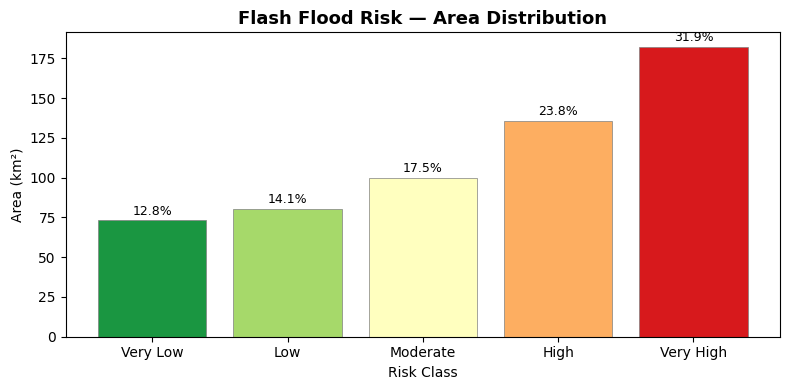

In [18]:
# ==========================================
# สถิติพื้นที่แต่ละ Risk Class
# BUG FIX: กำหนดสีตาม class จริงที่มีอยู่ ไม่ใช่ fixed 5 สี
# ==========================================
area_image = ee.Image.pixelArea().divide(1e6)

area_stats = area_image.addBands(risk_class).reduceRegion(
    reducer=ee.Reducer.sum().group(groupField=1, groupName='class'),
    geometry=AOI, scale=SCALE, maxPixels=1e9, bestEffort=True
)

area_groups = area_stats.getInfo()['groups']
area_df = pd.DataFrame(area_groups)

class_label_map = {1:'Very Low', 2:'Low', 3:'Moderate', 4:'High', 5:'Very High'}
class_color_map = {1:'#1a9641', 2:'#a6d96a', 3:'#ffffbf', 4:'#fdae61', 5:'#d7191c'}

area_df['class_label'] = area_df['class'].map(class_label_map)
area_df['area_km2']    = area_df['sum'].round(2)
area_df['percentage']  = (area_df['sum'] / area_df['sum'].sum() * 100).round(1)
# กำหนดสีตาม class ที่มีจริงเท่านั้น
area_df['color']       = area_df['class'].map(class_color_map)
area_df = area_df.sort_values('class')

print('\n📊 พื้นที่แต่ละระดับความเสี่ยง:')
print(area_df[['class_label','area_km2','percentage']].to_string(index=False))

# Bar chart — ใช้สีจาก area_df['color'] เพื่อหลีกเลี่ยง IndexError
import os
if not os.path.exists('figures'):
    os.makedirs('figures')

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(
    area_df['class_label'],
    area_df['area_km2'],
    color=area_df['color'].tolist(),  # สีตาม class จริง
    edgecolor='gray', linewidth=0.5
)
ax.set_title('Flash Flood Risk — Area Distribution', fontsize=13, fontweight='bold')
ax.set_xlabel('Risk Class')
ax.set_ylabel('Area (km²)')
for bar, pct in zip(bars, area_df['percentage']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + max(area_df['area_km2']) * 0.01,
            f'{pct}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('figures/area_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## ภารกิจที่ 3: Sensitivity Analysis

ทดสอบโดย **เปลี่ยนน้ำหนักของ TWI ±20%** และ **Plan Curvature ±20%**

In [19]:
def compute_ffri_with_weights(w_slope, w_dem, w_twi, w_plan_curv, w_ndvi,
                               w_soil, w_rain, w_river, w_lulc, w_jrc):
    """คำนวณ FFRI ด้วย weight set ที่กำหนด (ต้องรวม = 1.0)"""
    total = w_slope+w_dem+w_twi+w_plan_curv+w_ndvi+w_soil+w_rain+w_river+w_lulc+w_jrc
    assert abs(total - 1.0) < 0.01, f'Weights must sum to 1.0, got {total:.3f}'
    return (
        slope_n     .multiply(w_slope)
        .add(dem_inv_n    .multiply(w_dem))
        .add(twi_n        .multiply(w_twi))
        .add(plan_curv_n  .multiply(w_plan_curv))
        .add(ndvi_inv_n   .multiply(w_ndvi))
        .add(soil_moist_n .multiply(w_soil))
        .add(rainfall_n   .multiply(w_rain))
        .add(dist_inv_n   .multiply(w_river))
        .add(lulc_n       .multiply(w_lulc))
        .add(jrc_n        .multiply(w_jrc))
    ).rename('FFRI').clip(AOI)


def get_high_risk_area_km2(ffri_img, threshold=0.6):
    high_risk = ffri_img.gt(threshold)
    area = ee.Image.pixelArea().divide(1e6).updateMask(high_risk)
    result = area.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=AOI, scale=SCALE, maxPixels=1e9, bestEffort=True
    )
    return result.getInfo().get('area', 0)

print('✅ Helper functions defined')

✅ Helper functions defined


In [20]:
base_w = WEIGHTS.copy()

# --- Sensitivity Test 1: TWI weight ±20% (ชดเชยด้วย Slope) ---
twi_deltas = [-0.03, -0.015, 0.0, +0.015, +0.03]  # ±20% ของ 0.15
scenarios = []
for delta in twi_deltas:
    w_twi_new   = base_w['twi'] + delta
    w_slope_new = base_w['slope'] - delta
    if w_twi_new < 0 or w_slope_new < 0:
        continue
    ffri_test = compute_ffri_with_weights(
        w_slope_new, base_w['dem'], w_twi_new, base_w['plan_curv'],
        base_w['ndvi'], base_w['soil_moist'], base_w['rainfall'],
        base_w['river'], base_w['lulc'], base_w['jrc']
    )
    high_area = get_high_risk_area_km2(ffri_test, threshold=0.6)
    scenarios.append({
        'TWI_weight':   round(w_twi_new, 3),
        'Slope_weight': round(w_slope_new, 3),
        'delta_pct':    f'{delta/base_w["twi"]*100:+.0f}%',
        'high_risk_km2': round(high_area, 1)
    })

sa_df = pd.DataFrame(scenarios)
print('\n📊 Sensitivity Analysis — TWI Weight Variation:')
print(sa_df.to_string(index=False))


📊 Sensitivity Analysis — TWI Weight Variation:
 TWI_weight  Slope_weight delta_pct  high_risk_km2
      0.120         0.180      -20%            0.0
      0.135         0.165      -10%            0.0
      0.150         0.150       +0%            0.0
      0.165         0.135      +10%            0.0
      0.180         0.120      +20%            0.9


In [21]:
# --- Sensitivity Test 2: Plan Curvature weight ±20% ---
pc_deltas = [-0.02, -0.01, 0.0, +0.01, +0.02]  # ±20% ของ 0.10
scenarios_pc = []
for delta in pc_deltas:
    w_pc_new  = base_w['plan_curv'] + delta
    w_twi_new = base_w['twi'] - delta
    if w_pc_new < 0 or w_twi_new < 0:
        continue
    ffri_test = compute_ffri_with_weights(
        base_w['slope'], base_w['dem'], w_twi_new, w_pc_new,
        base_w['ndvi'], base_w['soil_moist'], base_w['rainfall'],
        base_w['river'], base_w['lulc'], base_w['jrc']
    )
    high_area = get_high_risk_area_km2(ffri_test, threshold=0.6)
    scenarios_pc.append({
        'PlanCurv_weight': round(w_pc_new, 3),
        'TWI_weight':      round(w_twi_new, 3),
        'delta_pct':       f'{delta/base_w["plan_curv"]*100:+.0f}%',
        'high_risk_km2':   round(high_area, 1)
    })

sa_pc_df = pd.DataFrame(scenarios_pc)
print('\n📊 Sensitivity Analysis — Plan Curvature Weight Variation:')
print(sa_pc_df.to_string(index=False))


📊 Sensitivity Analysis — Plan Curvature Weight Variation:
 PlanCurv_weight  TWI_weight delta_pct  high_risk_km2
            0.08        0.17      -20%              0
            0.09        0.16      -10%              0
            0.10        0.15       +0%              0
            0.11        0.14      +10%              0
            0.12        0.13      +20%              0


In [22]:
# --- Sensitivity Test 3: Rainfall weight ±20% ---
rain_deltas = [-0.03, -0.015, 0.0, +0.015, +0.03]
scenarios_rain = []
for delta in rain_deltas:
    w_rain_new  = base_w['rainfall'] + delta
    w_river_new = base_w['river'] - delta
    if w_rain_new < 0 or w_river_new < 0:
        continue
    ffri_test = compute_ffri_with_weights(
        base_w['slope'], base_w['dem'], base_w['twi'], base_w['plan_curv'],
        base_w['ndvi'], base_w['soil_moist'], w_rain_new,
        w_river_new, base_w['lulc'], base_w['jrc']
    )
    high_area = get_high_risk_area_km2(ffri_test, threshold=0.6)
    scenarios_rain.append({
        'Rainfall_weight': round(w_rain_new, 3),
        'River_weight':    round(w_river_new, 3),
        'delta_pct':       f'{delta/base_w["rainfall"]*100:+.0f}%',
        'high_risk_km2':   round(high_area, 1)
    })

sa_rain_df = pd.DataFrame(scenarios_rain)
print('\n📊 Sensitivity Analysis — Rainfall Weight Variation:')
print(sa_rain_df.to_string(index=False))


📊 Sensitivity Analysis — Rainfall Weight Variation:
 Rainfall_weight  River_weight delta_pct  high_risk_km2
           0.120         0.130      -20%            0.2
           0.135         0.115      -10%            0.0
           0.150         0.100       +0%            0.0
           0.165         0.085      +10%            0.0
           0.180         0.070      +20%            0.0


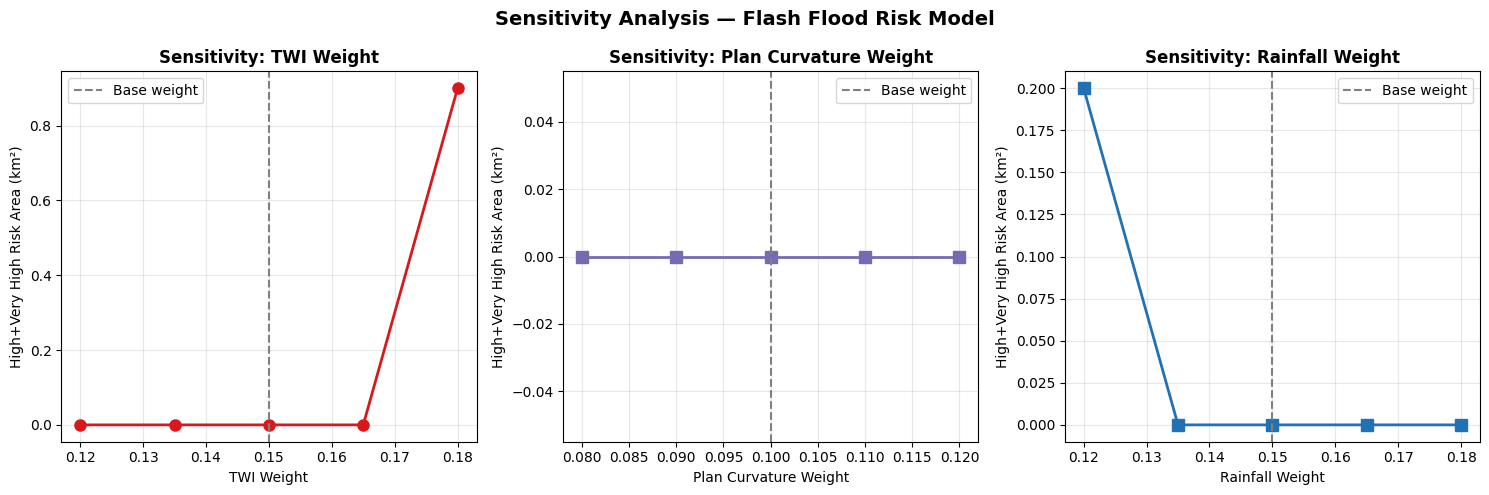


📊 TWI Sensitivity Summary:
   Base high-risk area : 0.0 km²
   Max variation: +inf% / nan%


In [23]:
# Plot Sensitivity Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax1 = axes[0]
ax1.plot(sa_df['TWI_weight'], sa_df['high_risk_km2'], 'o-', color='#d7191c', lw=2, markersize=8)
ax1.axvline(x=base_w['twi'], color='gray', linestyle='--', label='Base weight')
ax1.set_xlabel('TWI Weight'); ax1.set_ylabel('High+Very High Risk Area (km²)')
ax1.set_title('Sensitivity: TWI Weight', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(sa_pc_df['PlanCurv_weight'], sa_pc_df['high_risk_km2'], 's-', color='#756bb1', lw=2, markersize=8)
ax2.axvline(x=base_w['plan_curv'], color='gray', linestyle='--', label='Base weight')
ax2.set_xlabel('Plan Curvature Weight'); ax2.set_ylabel('High+Very High Risk Area (km²)')
ax2.set_title('Sensitivity: Plan Curvature Weight', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

ax3 = axes[2]
ax3.plot(sa_rain_df['Rainfall_weight'], sa_rain_df['high_risk_km2'], 's-', color='#2171b5', lw=2, markersize=8)
ax3.axvline(x=base_w['rainfall'], color='gray', linestyle='--', label='Base weight')
ax3.set_xlabel('Rainfall Weight'); ax3.set_ylabel('High+Very High Risk Area (km²)')
ax3.set_title('Sensitivity: Rainfall Weight', fontweight='bold')
ax3.legend(); ax3.grid(alpha=0.3)

plt.suptitle('Sensitivity Analysis — Flash Flood Risk Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/sensitivity_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

base_area = sa_df[sa_df['delta_pct']=='+0%']['high_risk_km2'].values[0]
max_area  = sa_df['high_risk_km2'].max()
min_area  = sa_df['high_risk_km2'].min()
print(f'\n📊 TWI Sensitivity Summary:')
print(f'   Base high-risk area : {base_area:.1f} km²')
print(f'   Max variation: +{(max_area-base_area)/base_area*100:.1f}% / {(min_area-base_area)/base_area*100:.1f}%')

In [24]:
# --- Robust vs Uncertain Areas ---
all_ffri_scenarios = []
for delta in twi_deltas:
    w_twi_new   = base_w['twi'] + delta
    w_slope_new = base_w['slope'] - delta
    if w_twi_new < 0 or w_slope_new < 0:
        continue
    ffri_s = compute_ffri_with_weights(
        w_slope_new, base_w['dem'], w_twi_new, base_w['plan_curv'],
        base_w['ndvi'], base_w['soil_moist'], base_w['rainfall'],
        base_w['river'], base_w['lulc'], base_w['jrc']
    )
    all_ffri_scenarios.append(ffri_s)

scenario_stack = ee.ImageCollection(all_ffri_scenarios)
ffri_std  = scenario_stack.reduce(ee.Reducer.stdDev()).rename('ffri_std').clip(AOI)
ffri_mean = scenario_stack.mean().rename('ffri_mean').clip(AOI)

robust    = ffri_std.lt(0.02).rename('robust')
uncertain = ffri_std.gte(0.05).rename('uncertain')

print('✅ Robust/Uncertain areas computed')
print('   Robust:    std < 0.02 → ผลคงที่ทุก scenario')
print('   Uncertain: std ≥ 0.05 → ผลไวต่อน้ำหนักมาก')

✅ Robust/Uncertain areas computed
   Robust:    std < 0.02 → ผลคงที่ทุก scenario
   Uncertain: std ≥ 0.05 → ผลไวต่อน้ำหนักมาก


## ภารกิจที่ 4: Validation

In [25]:


MAX_POINTS = 4000  # ปลอดภัย < 5000 limit ของ GEE

# Subsample ถ้ามีจุดมากกว่า MAX_POINTS
n_total = val_points.size().getInfo()
if n_total > MAX_POINTS:
    fraction = MAX_POINTS / n_total
    val_points_sample = val_points.randomColumn(seed=42).filter(
        ee.Filter.lt('random', fraction)
    )
    print(f'⚠️  จุด Validation ({n_total}) > {MAX_POINTS} → Subsample ด้วย fraction={fraction:.3f}')
else:
    val_points_sample = val_points
    print(f'✅ ใช้จุด Validation ทั้งหมด {n_total} จุด')

# ดึงค่า FFRI ที่ตำแหน่งของแต่ละ point
val_sampled = FFRI.sampleRegions(
    collection=val_points_sample,
    properties=['label'],
    scale=SCALE,
    geometries=False
)

# แปลงเป็น DataFrame
val_data = val_sampled.getInfo()
val_df   = pd.DataFrame([f['properties'] for f in val_data['features']])
val_df   = val_df.dropna(subset=['FFRI', 'label'])
val_df['label'] = val_df['label'].astype(int)

print(f'\n✅ สำเร็จ: ดึงค่า FFRI ครบ {len(val_df)} จุด')
print(f'   Flood    (label=1): {(val_df.label==1).sum()} จุด')
print(f'   No Flood (label=0): {(val_df.label==0).sum()} จุด')
print(f'\n   FFRI stats (Flood)   : mean={val_df[val_df.label==1].FFRI.mean():.3f}')
print(f'   FFRI stats (No Flood): mean={val_df[val_df.label==0].FFRI.mean():.3f}')
val_df.head(10)

⚠️  จุด Validation (11874) > 4000 → Subsample ด้วย fraction=0.337

✅ สำเร็จ: ดึงค่า FFRI ครบ 3957 จุด
   Flood    (label=1): 1930 จุด
   No Flood (label=0): 2027 จุด

   FFRI stats (Flood)   : mean=0.410
   FFRI stats (No Flood): mean=0.389


,FFRI,label
0,0.303995,0
1,0.410239,0
2,0.496783,0
3,0.414124,0
4,0.261224,0
5,0.265554,0
6,0.304903,0
7,0.387513,0
8,0.350176,0
9,0.406494,0


In [26]:
# ==========================================
# Step 2: แสดงจุด Validation บนแผนที่
# ==========================================
Map3 = geemap.Map()
Map3.centerObject(AOI, zoom=9)

Map3.addLayer(FFRI, {'min': 0, 'max': 1, 'palette': ['#1a9641', '#a6d96a', '#ffffbf', '#fdae61', '#d7191c']}, 'FFRI')

flood_pts    = val_points_sample.filter(ee.Filter.eq('label', 1))
nonflood_pts = val_points_sample.filter(ee.Filter.eq('label', 0))
Map3.addLayer(flood_pts,    {'color': 'red',  'pointRadius': 5}, 'Flood Points (label=1)')
Map3.addLayer(nonflood_pts, {'color': 'blue', 'pointRadius': 5}, 'Non-flood Points (label=0)')

# แก้ไข: แยก keys และ colors ออกจาก legend_dict และกำหนดสีเป็น RGB tuples
# เพื่อให้สอดคล้องกับข้อผิดพลาด 'The legend colors must be a list of tuples.'
legend_keys = ['Flood (label=1)', 'Non-flood (label=0)']
legend_colors_rgb = [(255, 0, 0), (0, 0, 255)] # สีแดงและสีน้ำเงินในรูปแบบ RGB tuples

Map3.add_legend(title='Validation Points', keys=legend_keys, colors=legend_colors_rgb)
Map3

Map(center=[17.167732372207748, 99.72800371682601], controls=(WidgetControl(options=['position', 'transparent_…

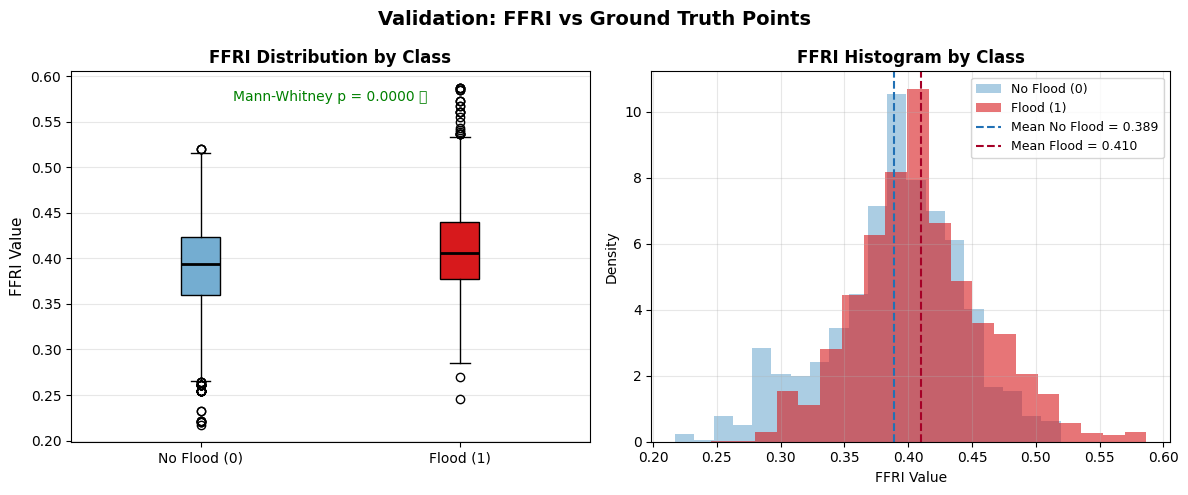


📊 Mann-Whitney U Test:
   H0: FFRI ของจุดน้ำท่วม ≤ จุดไม่ท่วม
   p-value = 0.0000
   ✅ Reject H0: โมเดลแยกแยะพื้นที่น้ำท่วมได้อย่างมีนัยสำคัญ


In [27]:
# ==========================================
# Step 3: Box Plot + Histogram + Mann-Whitney U Test
# ==========================================
from scipy import stats as scipy_stats

flood_vals    = val_df[val_df.label == 1]['FFRI'].values
nonflood_vals = val_df[val_df.label == 0]['FFRI'].values

u_stat, p_value = scipy_stats.mannwhitneyu(flood_vals, nonflood_vals, alternative='greater')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Box Plot
bp = axes[0].boxplot([nonflood_vals, flood_vals], labels=['No Flood (0)', 'Flood (1)', ],
                      patch_artist=True, medianprops={'color': 'black', 'linewidth': 2})
bp['boxes'][0].set_facecolor('#74add1')
bp['boxes'][1].set_facecolor('#d7191c')
axes[0].set_ylabel('FFRI Value', fontsize=11)
axes[0].set_title('FFRI Distribution by Class', fontsize=12, fontweight='bold')
axes[0].text(0.5, 0.95, f'Mann-Whitney p = {p_value:.4f}{" ✅" if p_value < 0.05 else " ⚠️"}',
             transform=axes[0].transAxes, ha='center', va='top', fontsize=10,
             color='green' if p_value < 0.05 else 'orange')
axes[0].grid(axis='y', alpha=0.3)

# Histogram
axes[1].hist(nonflood_vals, bins=20, alpha=0.6, color='#74add1', label='No Flood (0)', density=True)
axes[1].hist(flood_vals,    bins=20, alpha=0.6, color='#d7191c', label='Flood (1)',    density=True)
axes[1].axvline(nonflood_vals.mean(), color='#2171b5', linestyle='--', lw=1.5,
                label=f'Mean No Flood = {nonflood_vals.mean():.3f}')
axes[1].axvline(flood_vals.mean(),    color='#a50026', linestyle='--', lw=1.5,
                label=f'Mean Flood = {flood_vals.mean():.3f}')
axes[1].set_xlabel('FFRI Value'); axes[1].set_ylabel('Density')
axes[1].set_title('FFRI Histogram by Class', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(alpha=0.3)

plt.suptitle('Validation: FFRI vs Ground Truth Points', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/validation_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n📊 Mann-Whitney U Test:')
print(f'   H0: FFRI ของจุดน้ำท่วม ≤ จุดไม่ท่วม')
print(f'   p-value = {p_value:.4f}')
if p_value < 0.05:
    print('   ✅ Reject H0: โมเดลแยกแยะพื้นที่น้ำท่วมได้อย่างมีนัยสำคัญ')
else:
    print('   ⚠️  Fail to Reject H0: โมเดลไม่แยกแยะได้ดี — ทบทวน weights หรือ factors')


🎯 Best Threshold: 0.30  (F1 = 0.671)

📊 ROC-AUC: 0.592
   0.5=random | 0.7=acceptable | 0.8=good | 0.9=excellent

📊 Confusion Matrix (threshold=0.30):
   TP=1914  FP=1863  TN=164  FN=16
   Precision = 0.507
   Recall    = 0.992
   F1 Score  = 0.671


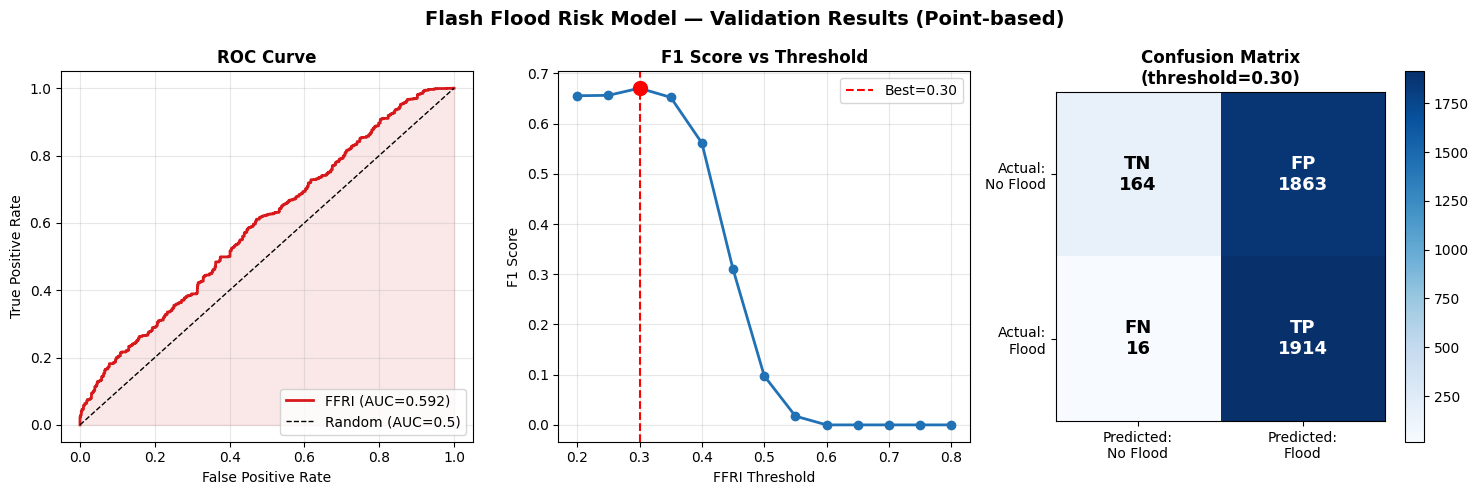

In [28]:
# ==========================================
# Step 4: ROC-AUC + Confusion Matrix + F1
# ==========================================
from sklearn.metrics import (
    confusion_matrix, roc_auc_score, roc_curve
)

# Moved f1_score import here because it was causing a NameError in the original notebook
from sklearn.metrics import f1_score

y_true  = val_df['label'].values
y_score = val_df['FFRI'].values

auc = roc_auc_score(y_true, y_score)
fpr, tpr, _ = roc_curve(y_true, y_score)

thresholds_test = np.arange(0.2, 0.85, 0.05)
f1_list = [f1_score(y_true, (y_score >= t).astype(int), zero_division=0) for t in thresholds_test]

best_t  = thresholds_test[np.argmax(f1_list)]
best_f1 = max(f1_list)

y_pred_best = (y_score >= best_t).astype(int)
cm = confusion_matrix(y_true, y_pred_best)
tn, fp, fn, tp = cm.ravel()
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall    = tp / (tp + fn) if (tp + fn) > 0 else 0

print(f'\n🎯 Best Threshold: {best_t:.2f}  (F1 = {best_f1:.3f})')
print(f'\n📊 ROC-AUC: {auc:.3f}')
print(f'   0.5=random | 0.7=acceptable | 0.8=good | 0.9=excellent')
print(f'\n📊 Confusion Matrix (threshold={best_t:.2f}):')
print(f'   TP={tp}  FP={fp}  TN={tn}  FN={fn}')
print(f'   Precision = {precision:.3f}')
print(f'   Recall    = {recall:.3f}')
print(f'   F1 Score  = {best_f1:.3f}')

# ----- Plot -----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].plot(fpr, tpr, color='#d7191c', lw=2, label=f'FFRI (AUC={auc:.3f})')
axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random (AUC=0.5)')
axes[0].fill_between(fpr, tpr, alpha=0.1, color='#d7191c')
axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve', fontweight='bold')
axes[0].legend(loc='lower right'); axes[0].grid(alpha=0.3)

axes[1].plot(thresholds_test, f1_list, 'o-', color='#2171b5', lw=2, markersize=6)
axes[1].axvline(x=best_t, color='red', linestyle='--', lw=1.5, label=f'Best={best_t:.2f}')
axes[1].scatter([best_t], [best_f1], color='red', s=100, zorder=5)
axes[1].set_xlabel('FFRI Threshold'); axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(alpha=0.3)

im = axes[2].imshow(cm, cmap='Blues')
axes[2].set_xticks([0,1]); axes[2].set_yticks([0,1])
axes[2].set_xticklabels(['Predicted:\nNo Flood', 'Predicted:\nFlood'], fontsize=10)
axes[2].set_yticklabels(['Actual:\nNo Flood', 'Actual:\nFlood'], fontsize=10)
labels_cm = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        color = 'white' if cm[i,j] > cm.max()*0.6 else 'black'
        axes[2].text(j, i, f'{labels_cm[i][j]}\n{cm[i,j]}',
                     ha='center', va='center', fontsize=13, color=color, fontweight='bold')
axes[2].set_title(f'Confusion Matrix\n(threshold={best_t:.2f})', fontweight='bold')
plt.colorbar(im, ax=axes[2])

plt.suptitle('Flash Flood Risk Model — Validation Results (Point-based)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('figures/validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# ==========================================
# Step 5: สรุปผล Validation
# ==========================================
print('=' * 55)
print('  Flash Flood Risk Model — Validation Summary')
print('=' * 55)
print(f'  Validation points    : {len(val_df)} จุด')
print(f'    - Flood (label=1)  : {(y_true==1).sum()} จุด')
print(f'    - No Flood (label=0): {(y_true==0).sum()} จุด')
print(f'  ROC-AUC              : {auc:.3f}')
print(f'  Best F1 Score        : {best_f1:.3f}  (threshold={best_t:.2f})')
print(f'  Precision            : {precision:.3f}')
print(f'  Recall               : {recall:.3f}')
print(f'  Mann-Whitney p-value : {p_value:.4f}')
print('=' * 55)

if auc >= 0.8:
    grade = '🟢 Good'
elif auc >= 0.7:
    grade = '🟡 Acceptable'
else:
    grade = '🔴 Poor — ควรทบทวนโมเดล'

print(f'  Model Performance    : {grade}')
print()
print('  ข้อสังเกต:')
if recall > precision:
    print('  - Recall > Precision: โมเดลจับพื้นที่น้ำท่วมได้มาก แต่ overpredict บ้าง')
else:
    print('  - Precision > Recall: โมเดลแม่น แต่อาจพลาดพื้นที่บางส่วน')

  Flash Flood Risk Model — Validation Summary
  Validation points    : 3957 จุด
    - Flood (label=1)  : 1930 จุด
    - No Flood (label=0): 2027 จุด
  ROC-AUC              : 0.592
  Best F1 Score        : 0.671  (threshold=0.30)
  Precision            : 0.507
  Recall               : 0.992
  Mann-Whitney p-value : 0.0000
  Model Performance    : 🔴 Poor — ควรทบทวนโมเดล

  ข้อสังเกต:
  - Recall > Precision: โมเดลจับพื้นที่น้ำท่วมได้มาก แต่ overpredict บ้าง


## 7. Export ผลลัพธ์

In [37]:
task1 = ee.batch.Export.image.toDrive(
    image=FFRI,
    description='Flash_Flood_Risk_Index_FFRI',
    folder='GEE_Lab4_FlashFlood',
    fileNamePrefix='ffri_continuous',
    region=AOI, scale=SCALE, crs='EPSG:4326', maxPixels=1e9
)
task1.start()

task2 = ee.batch.Export.image.toDrive(
    image=risk_class.toByte(),
    description='Flash_Flood_Risk_Class',
    folder='GEE_Lab4_FlashFlood',
    fileNamePrefix='ffri_class',
    region=AOI, scale=SCALE, crs='EPSG:4326', maxPixels=1e9
)
task2.start()

task3 = ee.batch.Export.image.toDrive(
    image=ffri_std,
    description='Flash_Flood_Model_Uncertainty',
    folder='GEE_Lab4_FlashFlood',
    fileNamePrefix='ffri_uncertainty',
    region=AOI, scale=SCALE, crs='EPSG:4326', maxPixels=1e9
)
task3.start()

print('✅ Export tasks started. Check GEE Tasks tab.')
print('   ไฟล์จะอยู่ใน Google Drive → GEE_Lab4_FlashFlood/')

✅ Export tasks started. Check GEE Tasks tab.
   ไฟล์จะอยู่ใน Google Drive → GEE_Lab4_FlashFlood/
